Read Data First:

In [1]:
from pandas import DataFrame, read_csv
df: DataFrame = read_csv(".csv")
print("Columns:", "\n".join(set(df.columns)))

Columns: Origin
Model
Length
Weight
EngineSize
DriveTrain
Horsepower
MPG.highway
Price
Fuel.tank.capacity
Unnamed: 0
Make
RPM
Rev.per.mile
Max.Price
Cylinders
Manufacturer
Man.trans.avail
Min.Price
Turn.circle
Luggage.room
Type
Wheelbase
MPG.city
Rear.seat.room
AirBags
Passengers
Width


# (a) Create a bar chart for the categorical variable "Manufacturer."


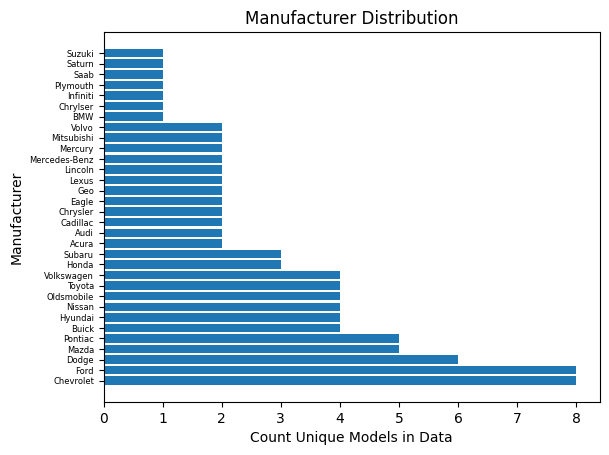

In [2]:
import matplotlib.pyplot as plt
from collections import Counter
manufacturers, counts = zip(*Counter(df["Manufacturer"]).most_common())
plt.barh(manufacturers, counts, )
plt.yticks(fontsize=6)
plt.title("Manufacturer Distribution", fontsize=12)
plt.xlabel("Count Unique Models in Data", fontsize=10)
plt.ylabel("Manufacturer", fontsize=10)
plt.show()

# (b) Create a bar chart for the categorical variable “Type.”


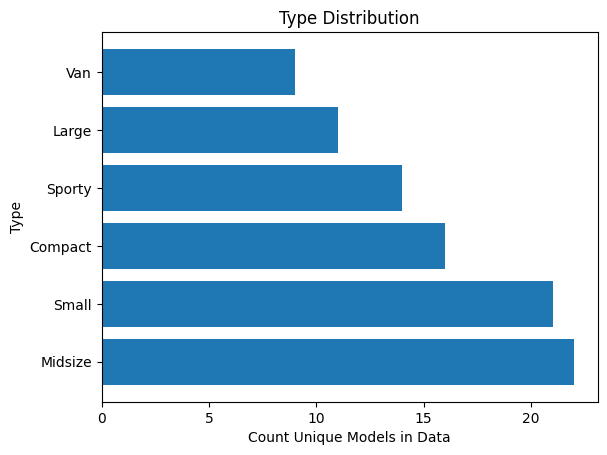

In [3]:
types, counts = zip(*Counter(df["Type"]).most_common())
plt.barh(types, counts, )
plt.yticks(fontsize=10)
plt.title("Type Distribution", fontsize=12)
plt.xlabel("Count Unique Models in Data", fontsize=10)
plt.ylabel("Type", fontsize=10)
plt.show()

# (c) What conclusions can you draw from the above two charts?

<span style="color:lightblue;">Because the car charts only reflect how many unique models fall within a category from a very specific dataset, there is little to learn about the real world, yet plenty to learn about how this data should be modeled and examined. Since these two charts are simple enough to need no explanation, I will refrain from reciting the information they explain. Instead, I will say that models made by manufacturers such as suzuki and saab presumably cannot be as closely examined as manufacturers such as Chrysler because they do not have a significant number of unique models represented. Therefore, when comparing these manufacturers it is important to keep in mind that much less is understood about these brands. Types, on the other hand, seem to be well represented across groups.

I would like to politely object the way that "bar charts" are referred to in this assignment and in Chapter 1.2.1. While these types of bar charts, "where the height of each bar is proportional to the number of items in that category" are legitimate bar charts, they are not the *only* types of bar charts. The term "bar chart" was coined by Joseph Priestley in the 1700s and represent categorical data with rectangular bars with heights proportional to the values that they represent, which includes, but is not limited to, the "number of items in that category".

Sources: https://think.design/services/data-visualization-data-design/bar-chart/#:~:text=History%20of%20Bar%20Chart&text=However%20many%20sources%20still%20consider,first%20bar%20chart%20in%20history,  https://journals.sagepub.com/doi/10.1177/14703572221130445</span>

# (d) Create density histograms for the variables Min.Price, Max.Price, Weight, and Length using a different color for each histogram using an appropriate number of bins.

In [ ]:
from math import floor, sqrt

# this is a general rule of thumb I use to determine how many bins should be represented
n_bins: int = floor(sqrt(len(df)))

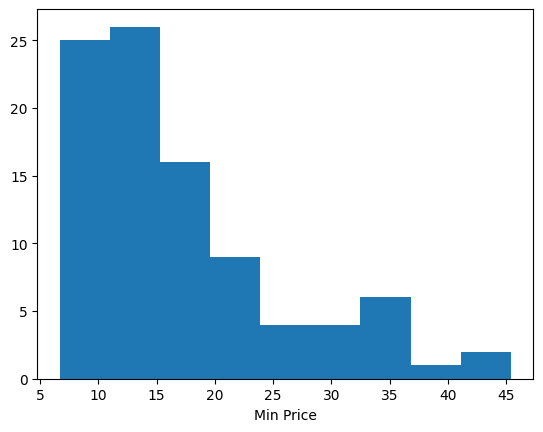

In [8]:
plt.hist(df["Min.Price"], bins=n_bins, color="red")
plt.xlabel("Min Price", fontsize=10)
plt.show()

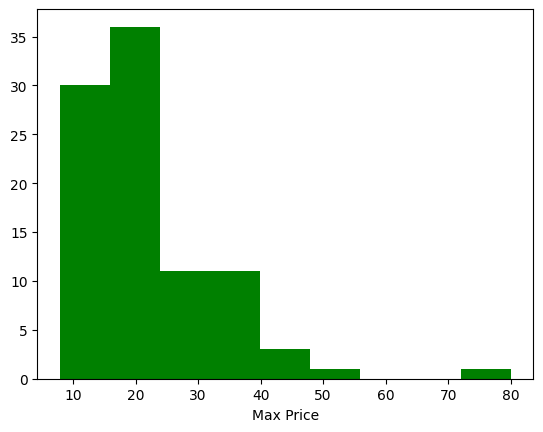

In [12]:
plt.hist(df["Max.Price"], bins=n_bins, color="green")
plt.xlabel("Max Price", fontsize=10)
plt.show()

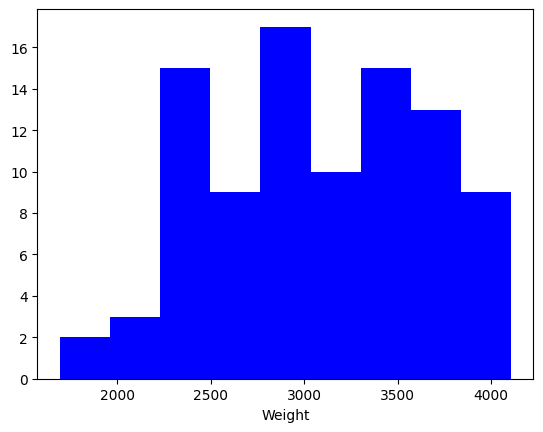

In [13]:
plt.hist(df["Weight"], bins=n_bins, color="blue")
plt.xlabel("Weight", fontsize=10)
plt.show()

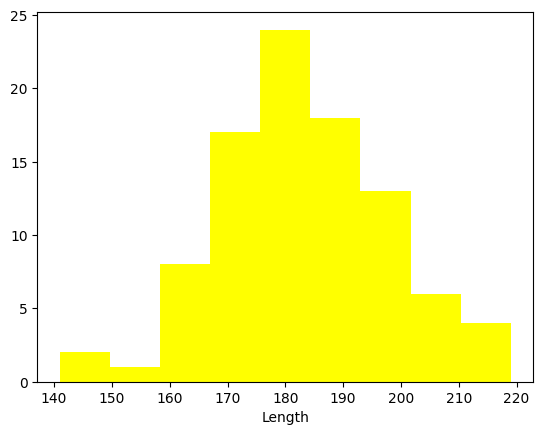

In [14]:
plt.hist(df["Length"], bins=n_bins, color="yellow")
plt.xlabel("Length", fontsize=10)
plt.show()

# (e) Superimpose normal density curves over the histograms in (d). Inspect and comment on which variables seem to follow the normal curve (bell shape) and which do not.


In [17]:
import numpy as np
from pandas import Series

def filter_outliers_iqr(column:Series) -> list:
    """
    Filters outliers from a DataFrame column using the IQR method.
    """

    # Calculate quantiles
    q1 = np.percentile(column, 25)
    q3 = np.percentile(column, 75)
    iqr = q3 - q1

    # Calculate upper and lower bounds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return [e for e in column if lower_bound <= e <= upper_bound]

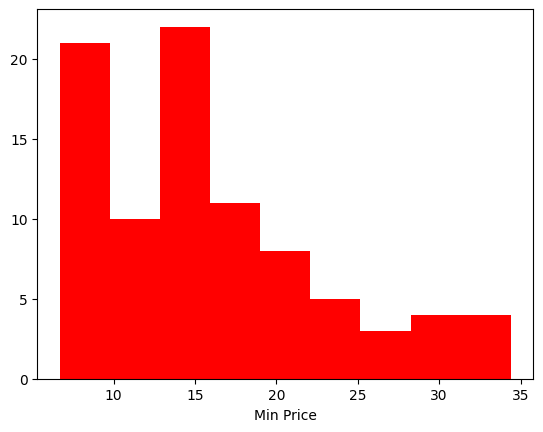

In [18]:
plt.hist(filter_outliers_iqr(df["Min.Price"]), bins=n_bins, color="red")
plt.xlabel("Min Price", fontsize=10)
plt.show()

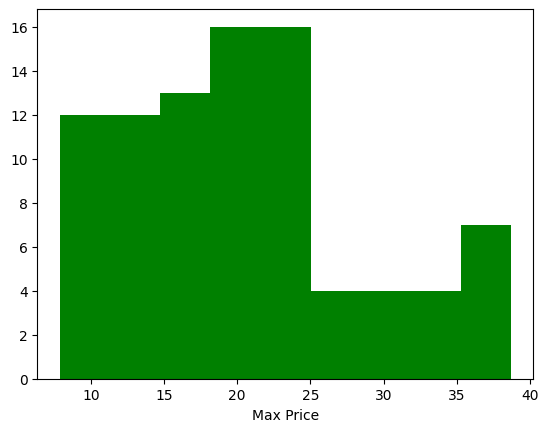

In [19]:
plt.hist(filter_outliers_iqr(df["Max.Price"]), bins=n_bins, color="green")
plt.xlabel("Max Price", fontsize=10)
plt.show()

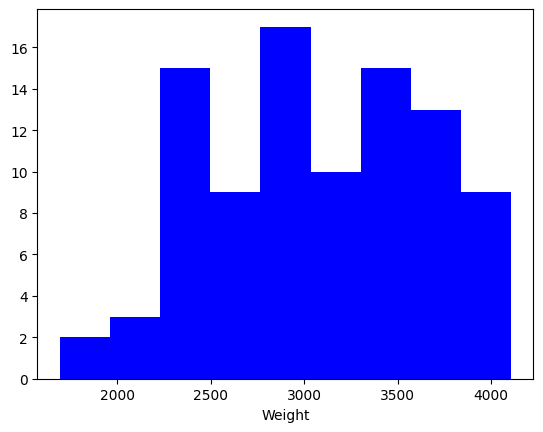

In [20]:
plt.hist(filter_outliers_iqr(df["Weight"]), bins=n_bins, color="blue")
plt.xlabel("Weight", fontsize=10)
plt.show()

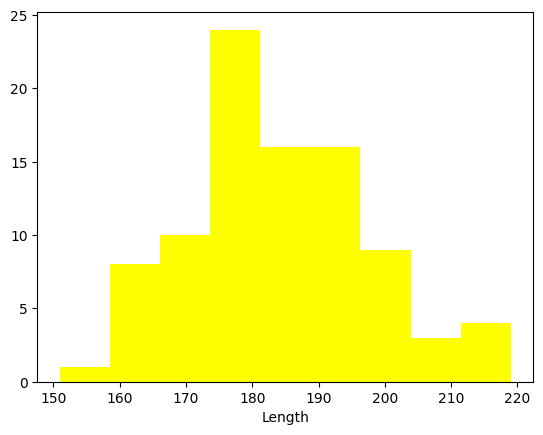

In [21]:
plt.hist(filter_outliers_iqr(df["Length"]), bins=n_bins, color="yellow")
plt.xlabel("Length", fontsize=10)
plt.show()

<span style="color:lightblue;">It seems like the only variable which follows a normal distribution would be the "Length" variable. However, since estimating whther a variable is close to normal is a very inexact art, one could argue that weight follows a normal distribution because the mean, median, and mode all seem to be very close together.</span>